Trial A:
lr = 5e-5
weights = [1,6,20,6]

In [1]:
import os
import cv2
import pickle
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import segmentation_models_pytorch as smp
import albumentations as A

c:\Users\HP\anaconda3\envs\dl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
BASE = r"C:\Users\HP\Desktop\GAVE2_preliminary\training"

with open("dataset_split.pkl", "rb") as f:
    split = pickle.load(f)

train_files = split["train"]
val_files = split["val"]
test_files = split["test"]

print(len(train_files), len(val_files), len(test_files))

35 7 8


In [4]:
train_transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=15, p=0.5),
        A.RandomBrightnessContrast(
            brightness_limit=0.15,
            contrast_limit=0.15,
            p=0.5
        )
    ],
    additional_targets={
        "fov": "mask"
    }
)

In [5]:
def convert_av_to_mask(av):
    mask = np.zeros(av.shape[:2], dtype=np.uint8)

    red = np.all(av == [255, 0, 0], axis=-1)
    green = np.all(av == [0, 255, 0], axis=-1)
    blue = np.all(av == [0, 0, 255], axis=-1)

    mask[red] = 1
    mask[green] = 2
    mask[blue] = 3

    return mask

In [6]:
def preprocess_retina(image, fov):
    image = image * fov[:, :, None]

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    r = clahe.apply(image[:, :, 0])
    g = clahe.apply(image[:, :, 1])
    b = clahe.apply(image[:, :, 2])

    enhanced = np.stack([r, g, b], axis=-1)

    return enhanced

In [7]:
class AVDataset(Dataset):
    def __init__(self, file_list, base_path, transform=None, resize=(1152, 768)):
        self.file_list = file_list
        self.base_path = base_path
        self.transform = transform
        self.resize = resize

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        filename = self.file_list[idx]

        image_path = os.path.join(self.base_path, "images", filename)
        av_path = os.path.join(self.base_path, "av", filename)
        fov_path = os.path.join(self.base_path, "masks", filename)

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        av = cv2.imread(av_path)
        av = cv2.cvtColor(av, cv2.COLOR_BGR2RGB)

        fov = cv2.imread(fov_path, 0)
        fov = (fov > 0).astype(np.uint8)

        mask = convert_av_to_mask(av)

        if self.transform:
            augmented = self.transform(
                image=image,
                mask=mask,
                fov=fov
            )
            image = augmented["image"]
            mask = augmented["mask"]
            fov = augmented["fov"]

        image = preprocess_retina(image, fov)

        image = cv2.resize(image, self.resize)
        mask = cv2.resize(mask, self.resize, interpolation=cv2.INTER_NEAREST)

        image = image.astype(np.float32) / 255.0
        image = np.transpose(image, (2, 0, 1))

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask

In [8]:
train_dataset = AVDataset(train_files, BASE, transform=train_transform)
val_dataset = AVDataset(val_files, BASE)
test_dataset = AVDataset(test_files, BASE)

In [9]:
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

In [10]:
model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b2",
    encoder_weights="imagenet",
    in_channels=3,
    classes=4
).to(device)

In [11]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(
            inputs,
            targets,
            weight=self.alpha,
            reduction='none'
        )

        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        return focal_loss.mean()

In [12]:
class CombinedLoss(nn.Module):
    def __init__(self, class_weights):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=class_weights)
        self.focal = FocalLoss(alpha=class_weights)

    def forward(self, preds, targets):
        ce_loss = self.ce(preds, targets)
        focal_loss = self.focal(preds, targets)

        return 0.5 * ce_loss + 0.5 * focal_loss

In [13]:
class_weights = torch.tensor([1.0, 6.0, 20.0, 6.0]).to(device)
criterion = CombinedLoss(class_weights)

In [14]:
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)

In [15]:
def calculate_metrics(preds, targets, num_classes=4):
    preds = torch.argmax(preds, dim=1)

    precisions = []
    recalls = []
    f1s = []
    ious = []

    eps = 1e-7

    for cls in range(1, num_classes):
        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        TP = (pred_cls * target_cls).sum()
        FP = (pred_cls * (1 - target_cls)).sum()
        FN = ((1 - pred_cls) * target_cls).sum()

        precision = TP / (TP + FP + eps)
        recall = TP / (TP + FN + eps)
        f1 = 2 * precision * recall / (precision + recall + eps)
        iou = TP / (TP + FP + FN + eps)

        precisions.append(precision.item())
        recalls.append(recall.item())
        f1s.append(f1.item())
        ious.append(iou.item())

    return {
        "precision": np.mean(precisions),
        "recall": np.mean(recalls),
        "f1": np.mean(f1s),
        "iou": np.mean(ious)
    }

In [16]:
from skimage.morphology import skeletonize

def cldice_score(preds, targets):
    preds = torch.argmax(preds, dim=1)

    preds = preds.cpu().numpy()
    targets = targets.cpu().numpy()

    scores = []
    eps = 1e-6

    for i in range(len(preds)):
        pred_bin = (preds[i] > 0).astype(np.uint8)
        target_bin = (targets[i] > 0).astype(np.uint8)

        pred_skel = skeletonize(pred_bin).astype(np.uint8)
        target_skel = skeletonize(target_bin).astype(np.uint8)

        tprec = (
            np.logical_and(pred_skel, target_bin).sum()
        ) / (pred_skel.sum() + eps)

        tsens = (
            np.logical_and(target_skel, pred_bin).sum()
        ) / (target_skel.sum() + eps)

        cldice = (2 * tprec * tsens) / (tprec + tsens + eps)

        scores.append(cldice)

    return np.mean(scores)

In [17]:
def cldice_score(preds, targets):
    preds = torch.argmax(preds, dim=1)

    preds = preds.cpu().numpy()
    targets = targets.cpu().numpy()

    scores = []

    for i in range(len(preds)):
        pred_bin = (preds[i] > 0).astype(np.uint8)
        target_bin = (targets[i] > 0).astype(np.uint8)

        intersection = np.logical_and(pred_bin, target_bin).sum()
        union = pred_bin.sum() + target_bin.sum()

        score = (2 * intersection + 1e-6) / (union + 1e-6)
        scores.append(score)

    return np.mean(scores)

In [18]:
def compute_accuracy(preds, targets):
    preds = torch.argmax(preds, dim=1)
    return (preds == targets).float().mean().item()

In [19]:
def multiclass_dice(preds, targets, num_classes=4, smooth=1e-6):
    preds = torch.argmax(preds, dim=1)

    dice_scores = []

    for cls in range(1, num_classes):  
        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()

        dice = (2 * intersection + smooth) / (union + smooth)
        dice_scores.append(dice.item())

    return np.mean(dice_scores)

In [20]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0
    total_acc = 0
    total_dice = 0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        acc = compute_accuracy(outputs, masks)
        dice = multiclass_dice(outputs, masks)

        total_loss += loss.item()
        total_acc += acc
        total_dice += dice

    return (
        total_loss / len(loader),
        total_acc / len(loader),
        total_dice / len(loader)
    )

In [21]:
def validate(model, loader, criterion):
    model.eval()

    total_loss = 0
    total_acc = 0
    total_dice = 0
    total_cldice = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            acc = compute_accuracy(outputs, masks)
            dice = multiclass_dice(outputs, masks)
            cld = cldice_score(outputs, masks)

            total_loss += loss.item()
            total_acc += acc
            total_dice += dice
            total_cldice += cld

    return (
        total_loss / len(loader),
        total_acc / len(loader),
        total_dice / len(loader),
        total_cldice / len(loader)
    )

In [22]:
best_val_cldice = 0
EPOCHS = 20

In [23]:
for epoch in range(EPOCHS):
    train_loss, train_acc, train_dice = train_one_epoch(
        model, train_loader, optimizer, criterion
    )

    val_loss, val_acc, val_dice, val_cldice = validate(
        model, val_loader, criterion
    )

    if val_cldice > best_val_cldice:
        best_val_cldice = val_cldice
        torch.save(model.state_dict(), "best_exp6_trialA.pth")
        print("Best model saved.")

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train Dice: {train_dice:.4f}")
    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val Dice: {val_dice:.4f} | "
        f"Val CLDice: {val_cldice:.4f}"
    )
    print("-"*50)

Best model saved.
Epoch 1/20
Train Loss: 1.4237 | Train Acc: 0.3662 | Train Dice: 0.0461
Val Loss: 1.3786 | Val Acc: 0.0497 | Val Dice: 0.0362 | Val CLDice: 0.1165
--------------------------------------------------
Epoch 2/20
Train Loss: 1.1921 | Train Acc: 0.4563 | Train Dice: 0.0714
Val Loss: 1.2998 | Val Acc: 0.2551 | Val Dice: 0.0482 | Val CLDice: 0.1121
--------------------------------------------------
Best model saved.
Epoch 3/20
Train Loss: 1.0617 | Train Acc: 0.5724 | Train Dice: 0.0982
Val Loss: 1.1719 | Val Acc: 0.7117 | Val Dice: 0.0695 | Val CLDice: 0.1650
--------------------------------------------------
Best model saved.
Epoch 4/20
Train Loss: 0.9634 | Train Acc: 0.6768 | Train Dice: 0.1286
Val Loss: 1.0231 | Val Acc: 0.8822 | Val Dice: 0.1006 | Val CLDice: 0.2513
--------------------------------------------------
Best model saved.
Epoch 5/20
Train Loss: 0.8873 | Train Acc: 0.7486 | Train Dice: 0.1533
Val Loss: 0.9362 | Val Acc: 0.9216 | Val Dice: 0.1153 | Val CLDice: 0

In [24]:
def mask_to_rgb(mask):
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)

    rgb[mask == 1] = [255, 0, 0]   # artery
    rgb[mask == 2] = [0, 255, 0]   # overlap
    rgb[mask == 3] = [0, 0, 255]   # vein

    return rgb

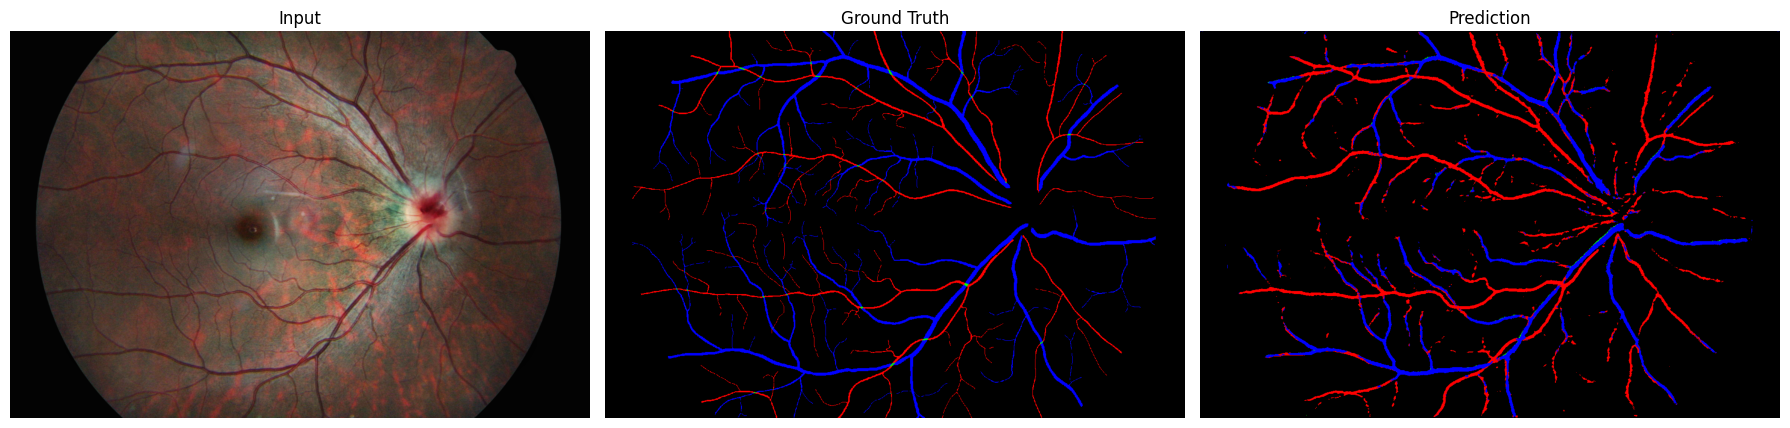

In [25]:
images, masks = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

img = images[0].cpu().permute(1, 2, 0).numpy()
gt = masks[0].cpu().numpy()
pred = preds[0].cpu().numpy()

gt_rgb = mask_to_rgb(gt)
pred_rgb = mask_to_rgb(pred)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(img)
ax[0].set_title("Input")

ax[1].imshow(gt_rgb)
ax[1].set_title("Ground Truth")

ax[2].imshow(pred_rgb)
ax[2].set_title("Prediction")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

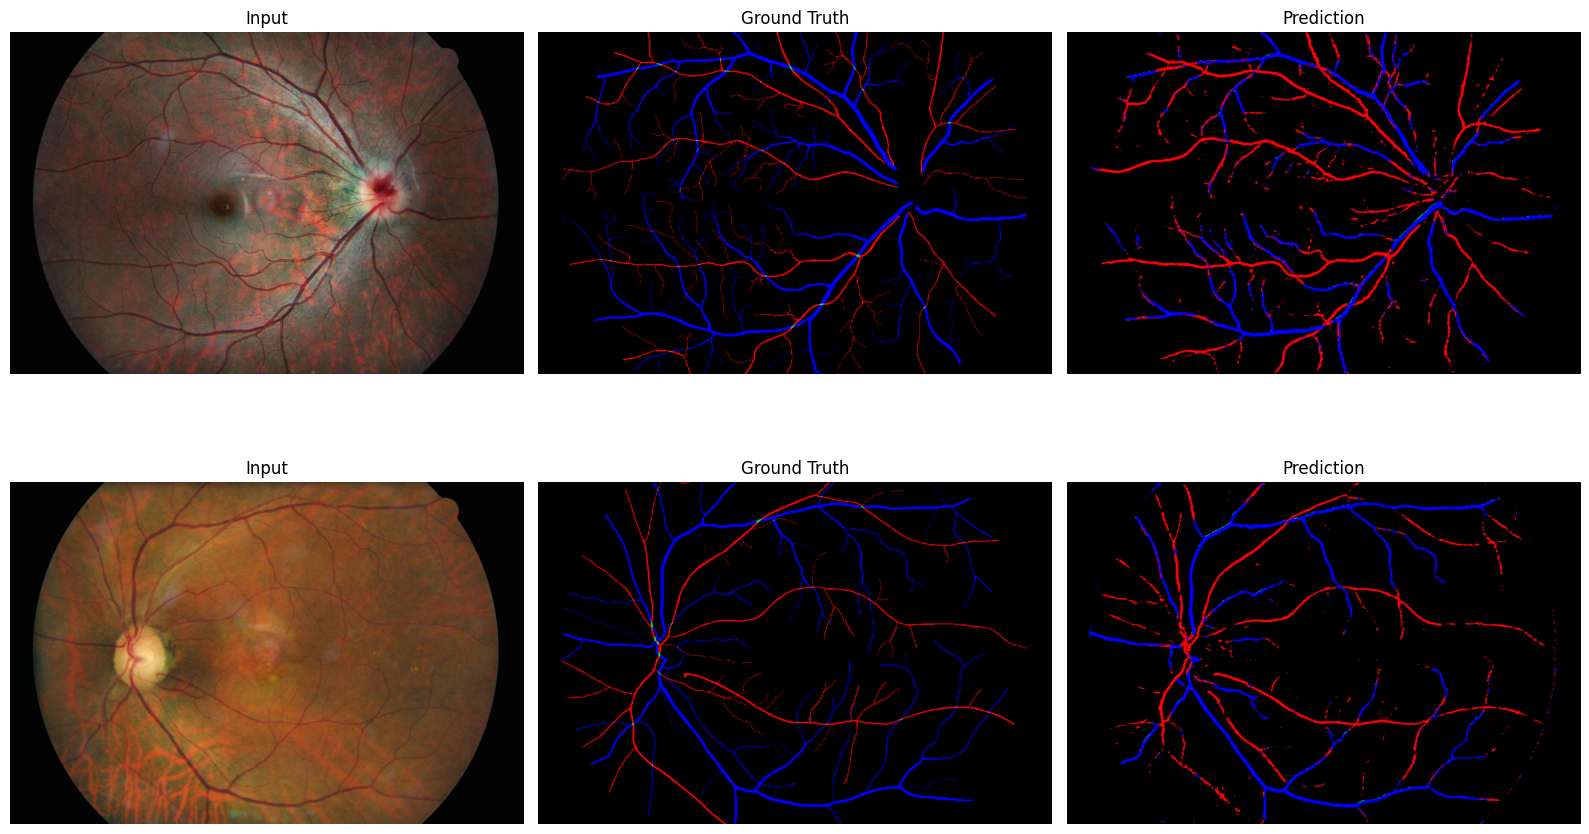

In [26]:
images, masks = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

num_samples = images.shape[0]

fig, axes = plt.subplots(num_samples, 3, figsize=(16, 5*num_samples))

if num_samples == 1:
    axes = np.expand_dims(axes, axis=0)

for i in range(num_samples):
    img = images[i].cpu().permute(1, 2, 0).numpy()
    gt = masks[i].cpu().numpy()
    pred = preds[i].cpu().numpy()

    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Input")

    axes[i, 1].imshow(mask_to_rgb(gt))
    axes[i, 1].set_title("Ground Truth")

    axes[i, 2].imshow(mask_to_rgb(pred))
    axes[i, 2].set_title("Prediction")

    for j in range(3):
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

In [27]:
model.load_state_dict(torch.load("best_exp6_trialA.pth"))
model.eval()

all_metrics = []
all_cldice = []

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        metrics = calculate_metrics(outputs, masks)
        cldice = cldice_score(outputs, masks)

        all_metrics.append(metrics)
        all_cldice.append(cldice)

precision = np.mean([m["precision"] for m in all_metrics])
recall = np.mean([m["recall"] for m in all_metrics])
f1 = np.mean([m["f1"] for m in all_metrics])
iou = np.mean([m["iou"] for m in all_metrics])
cldice = np.mean(all_cldice)

print("FINAL TEST METRICS")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"IoU       : {iou:.4f}")
print(f"CLDice    : {cldice:.4f}")

FINAL TEST METRICS
Precision : 0.3532
Recall    : 0.4394
F1 Score  : 0.3892
IoU       : 0.2768
CLDice    : 0.6847
